# T01 - Caminata aleatoria
##### Maria Fernanda Gómez Flores
##### Jueves 27 de Agosto 2026

## 1. Simulación del movimiento browniano

El movimiento browniano es el movimiento aleatorio que se observa en las partículas que se hallan en un medio fluido, como resultado de choques contra las moléculas de dicho fluido.

Para simular el movimiento, en lugar de usar las ecuaciones integro-diferenciales que describe Einstein, use una caminata aleatoria para los tres ejes \(x\), \(y\), \(z\) de la siguiente forma:

$$
W_i = W_{i-1} + X_i\sqrt{\Delta t}
$$

donde, \(\Delta t\) es un intervalo de tiempo y

$$
X_i =
\begin{cases}
1\\
-1
\end{cases}
$$

se escoge de forma aleatoria con la misma probabilidad.

**Simule 10 segundos con un \(\Delta t = 0.001\) y represéntelo en un gráfico 3D.** 


### Importar Librerias

In [1]:
#importar librerias
import numpy as np
import matplotlib.pyplot as plt

### Operaciones Ejercicio

In [2]:
#Sacar el valor de "n"  para ver ctos pasos  o movimientos va a hacer la partícula
dt=0.001
T=10
n= int(T/dt)
n

10000

In [3]:
#Crear listas [0] porque la partícula inicia en la posición 0.
x = [0]
y = [0]
z = [0]

#Ciclo para repetir las instrucciones "n" veces
for i in range(n):

#Elegir aleatoriamente los valores para X,Y y Z valores de -1 o  1
    Valor_X = np.random.choice([-1, 1])
    Valor_Y = np.random.choice([-1, 1])
    Valor_Z = np.random.choice([-1, 1])
# usar la formula del ejercicio y ponerlo en las listas antes creadas de x,y y z
    x.append(x[-1] + Valor_X * np.sqrt(dt))
    y.append(y[-1] + Valor_Y * np.sqrt(dt))
    z.append(z[-1] + Valor_Z * np.sqrt(dt))


### Grafico 3D

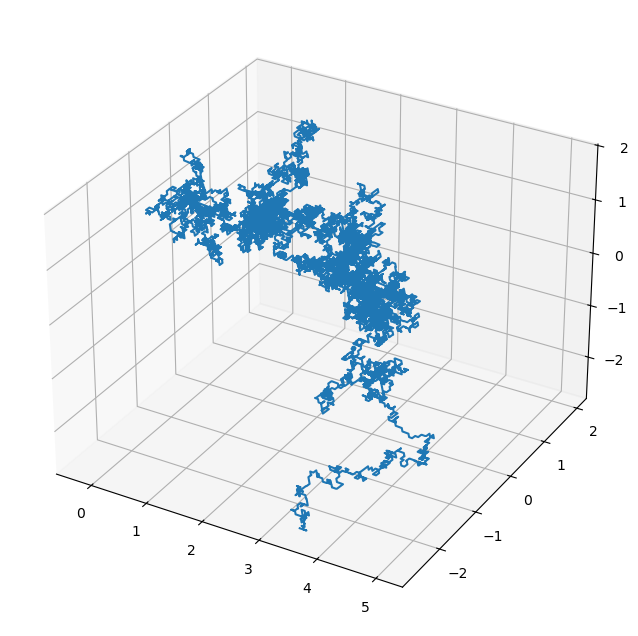

In [4]:
#Crea una figura vacia
fig = plt.figure(figsize=(10,8))
#la convierte a una figura en 3D
ax = plt.axes(projection='3d')
#lo aplica a las variables
ax.plot(x, y, z)
plt.show()

## 2. Apuesta Arriesgada

Un jugador, con 20 pesos de capital inicial, decide apostar a un volado (con una moneda perfectamente nivelada) la mitad de su capital si éste es mayor o igual a 6 pesos, de lo contrario, solo 2. Esto es, el capital \(C_i\) en cada volado \(V_i\) se describe como

$$ C_{i+1}=C_i+V_iA_i $$

donde la apuesta es

$$ A_i= \begin{cases} C_i/2, & \text{si } C_i \geq 6\\ 2, & \text{de lo contrario.} \end{cases} $$
1. Grafique la evolución del capital hasta quedar en cero.    
2. Determine el número de volados promedio para quedar en quiebra usando la simulación montecarlo para 10,000 apostadores.    
3. Muestre un histograma del número de volados.


### 1.

In [5]:

#Capital inciial
capital = 20
#inicia en 20 y se crea lista para guardarlos
capitales =[20]
#Contar cada volado
volados = 0

#Repetir hasta que el capital llegue a 0
while capital > 0:

#Aleatorio para ver si gana o pierde
        V = np.random.choice([-1, 1])

#Ver cuanto va a apostar
        if capital >= 6:
            apuesta = capital / 2
        else:
            apuesta = 2

#Formula ejercicio para nuevo capital
        capital = capital + V * apuesta

#Si el capital queda menor a 0 dejarlo en 0
        if capital < 0:
            capital = 0
            
    #Guardar el nuevo capital en la lista
        capitales.append(capital)

#Contar cada volado
        volados = volados + 1



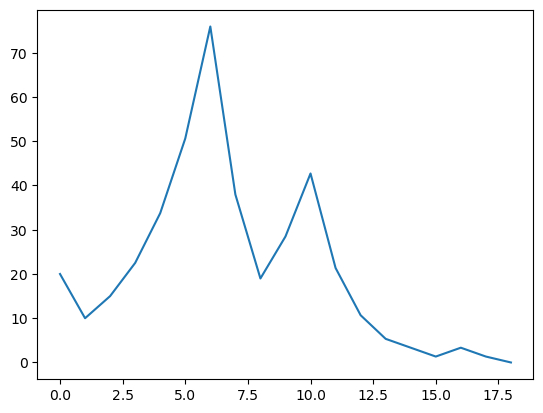

In [6]:
plt.plot(capitales)
plt.show()

### 2.


In [7]:
#Simulación Montecarlo 10,000 apostadores
M = 10000
numero_volados = []

In [8]:
#Esto lo que hace es repetir la simulación 10000 veces
for i in range(M):

#Reiniciar capital para cada apostador
    capital = 20

#Contar cada volado
    volados = 0

#Repetir hasta que el capital llegue a 0
    while capital > 0:

#Aleatorio para ver si gana o pierde
        V = np.random.choice([-1, 1])

#Ver cuanto va a apostar
        if capital >= 6:
            apuesta = capital / 2
        else:
            apuesta = 2

#Formula ejercicio para nuevo capital
        capital = capital + V * apuesta

#Si el capital queda menor a 0 dejarlo en 0
        if capital < 0:
            capital = 0

#Contar cada volado
        volados = volados + 1

#Guardar el numero de volados de cada apostador 
    numero_volados.append(volados)

In [9]:
#para ver si si tengo los 10,000
len(numero_volados)

10000

In [10]:
#Promedio de volados para quedar en quiebra
promedio = np.mean(numero_volados)
promedio

np.float64(26.2661)

El número promedio de volados para quedar en quiebra fue de aproximadamente 26.2661 volados

### 3.


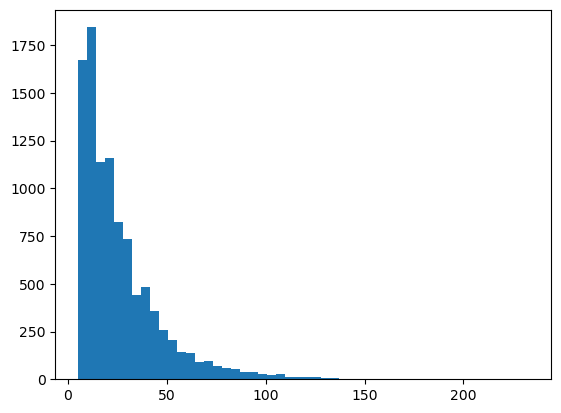

In [11]:
#Histograma
plt.hist(numero_volados, bins=50)
plt.show()